## Canny Extraction

In [22]:
import cv2
import matplotlib.pylab as plt
import numpy as np

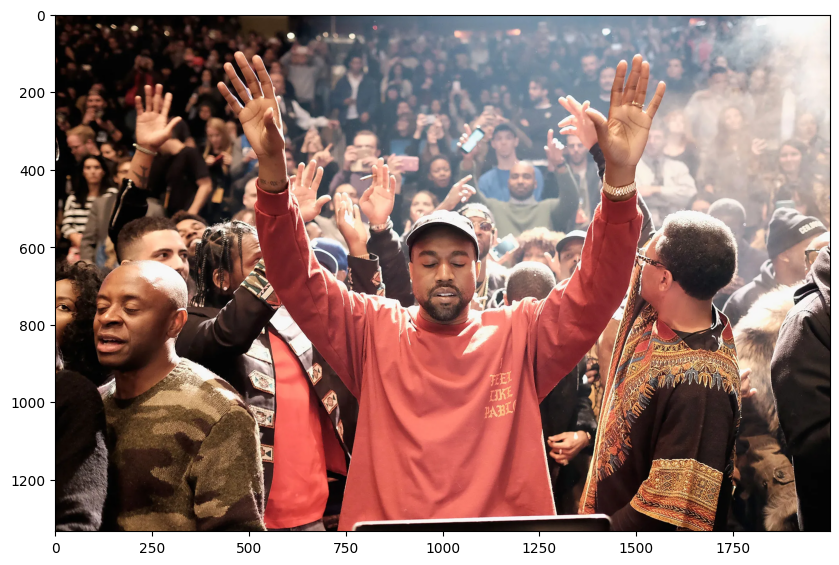

In [5]:
kanye_img = cv2.imread('./kanye.jpg')
kanye_img = cv2.cvtColor(kanye_img, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(kanye_img)
plt.show()

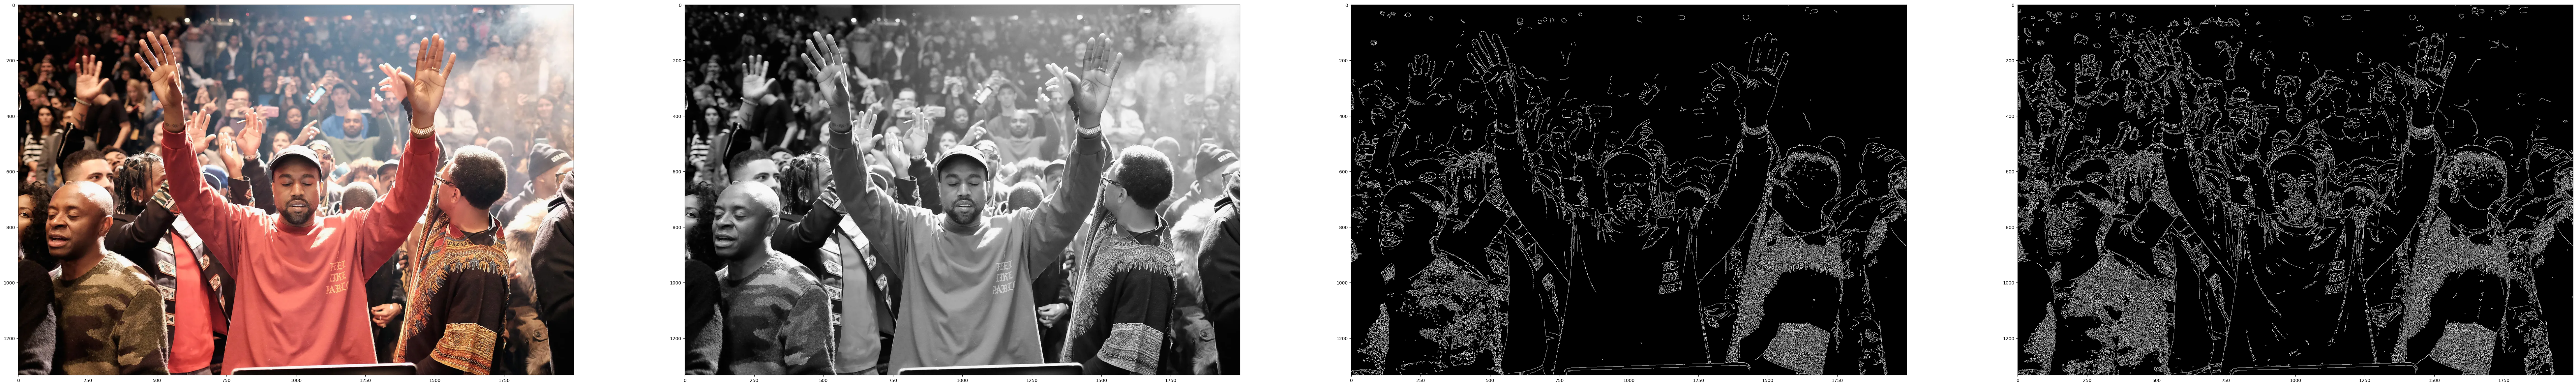

In [25]:
# Canny Edge Detection
gray_kanye = cv2.cvtColor(kanye_img, cv2.COLOR_RGB2GRAY)
fig, axs = plt.subplots(1, 4, figsize=(100, 100))

# Base Image
axs[0].imshow(kanye_img)

# Gray Image
axs[1].imshow(gray_kanye, cmap='gray')

# Canny Edges Image T1 = 100, T2 = 200
edges1 = cv2.Canny(gray_kanye, 100, 200)
axs[2].imshow(edges1, cmap='gray')

# Canny Edges Image T1 = 50, T2 = 100
edges2 = cv2.Canny(gray_kanye, 50, 100)
axs[3].imshow(edges2, cmap='gray')

plt.show()

## Contours

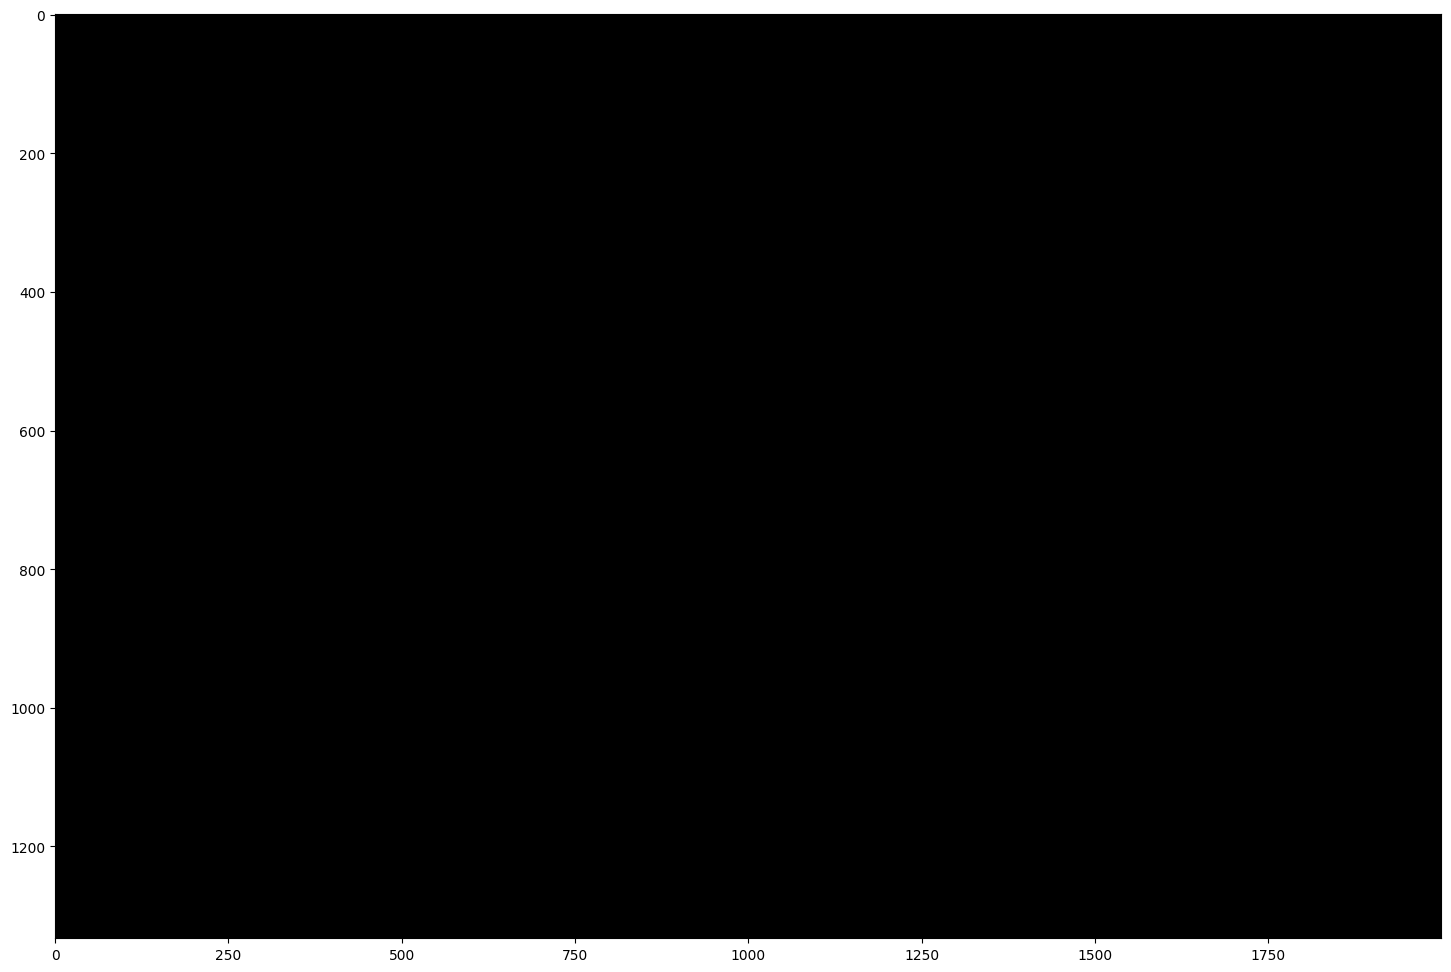

In [41]:
contours, hierarchy = cv2.findContours(edges1,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
edges_contours = cv2.drawContours(edges1, contours, -1, (0, 255, 0), 3)

plt.figure(figsize=(24, 12))
plt.imshow(edges_contours, cmap='gray')

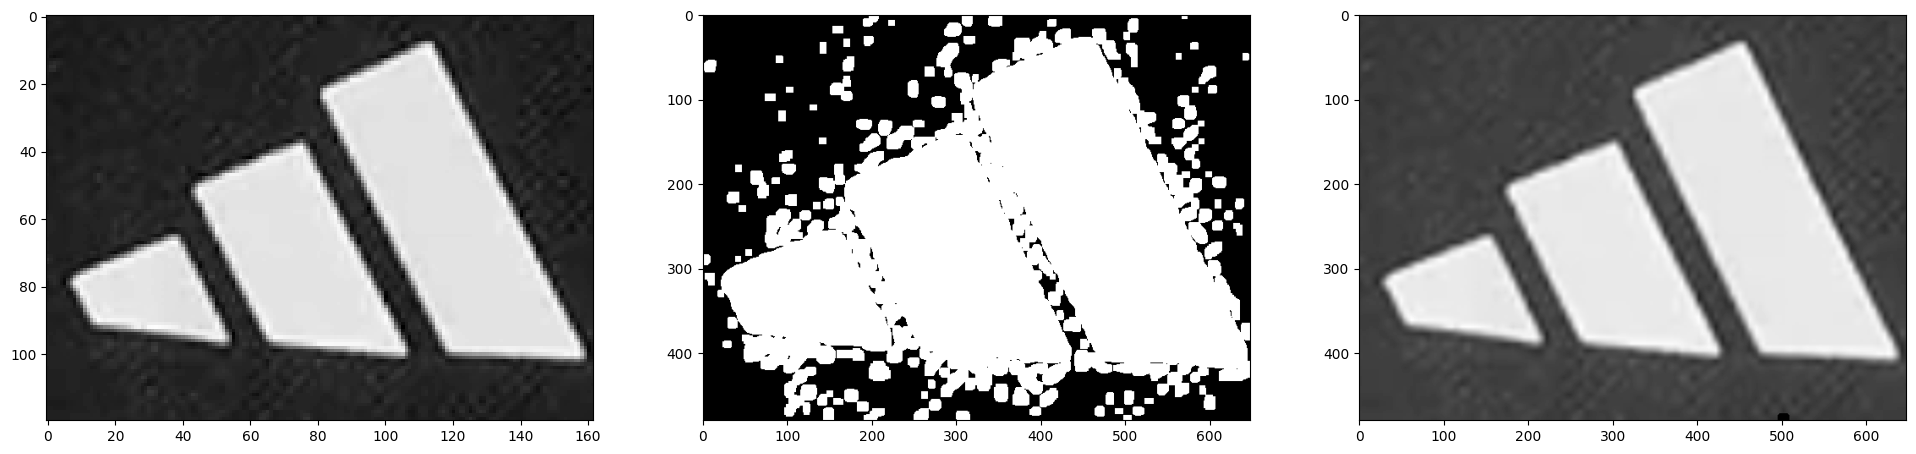

In [38]:
plt.figure(figsize=(24, 12))

america_img = cv2.imread('./adidas.png')
gray_america_image = cv2.cvtColor(america_img, cv2.COLOR_BGR2GRAY)
plt.subplot(231)
plt.imshow(gray_america_image, cmap='gray')

height, width = gray_america_image.shape
scale = 4
heightScale = int(scale*height)
widthScale = int(scale*width)
big_gray_america_image = cv2.resize(gray_america_image, (widthScale, heightScale))

_, thresh = cv2.threshold(big_gray_america_image, 65, 255, cv2.THRESH_BINARY)
kernel = np.ones((7, 7), np.uint8)
thresh = cv2.dilate(thresh, kernel)
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = [contours[0]]
cv2.drawContours(big_gray_america_image, contours, -1, (0, 0, 255), 3)

plt.subplot(232)
plt.imshow(thresh, cmap="gray")
plt.subplot(233)
plt.imshow(big_gray_america_image, cmap="gray")

plt.show()